Este notebook muestra un fichero que se ha utilizado una instancia para evaluar diferentes parámetros para el algoritmo genético.

Para dicha instancia se prueben diferentes combinaciones de población inicial, tasa de cruce, tasa de mutación y tasa de arreglo.

Los resultados obtenidos se recopilaban en un fichero txt para obtener los mejor valores encontrados probados en diferentes instancias

In [ ]:
SEED = 39
import random
random.seed(SEED)
n_objetos = 200
capacidad_mochila = 600

limite_objetos = n_objetos // 3

objetos_peso = [random.randint(3, 60) for _ in range(n_objetos)]
objetos_valor = [random.randint(10, 150) for _ in range(n_objetos)]
objetos_cantidad = [random.randint(2, 15) for _ in range(n_objetos)]

print("Pesos:", objetos_peso)
print("Valores:", objetos_valor)
print("Cantidades:", objetos_cantidad)
print("Capacidad mochila:", capacidad_mochila)

N = len(objetos_peso)

Pesos: [16, 19, 27, 4, 15, 17, 28, 49, 39, 3, 44, 54, 19, 46, 25, 48, 14, 55, 4, 21, 46, 59, 57, 7, 26, 3, 9, 30, 25, 30, 53, 51, 9, 58, 28, 35, 40, 22, 20, 48, 7, 32, 30, 19, 39, 23, 39, 3, 49, 48, 58, 5, 44, 15, 42, 60, 42, 33, 42, 51, 43, 27, 54, 23, 54, 21, 27, 44, 25, 33, 11, 36, 30, 7, 14, 22, 46, 51, 21, 18, 53, 47, 49, 47, 56, 9, 28, 54, 49, 58, 33, 35, 8, 29, 5, 4, 49, 49, 45, 29, 3, 59, 41, 39, 40, 44, 27, 47, 11, 55, 50, 60, 60, 38, 42, 17, 10, 37, 31, 44, 15, 36, 59, 54, 55, 17, 57, 59, 48, 18, 11, 37, 8, 42, 52, 34, 24, 59, 60, 35, 20, 58, 50, 58, 16, 56, 35, 15, 58, 54, 40, 12, 14, 13, 26, 23, 21, 14, 5, 10, 16, 39, 7, 58, 17, 6, 9, 44, 59, 10, 9, 53, 32, 59, 38, 32, 55, 25, 20, 45, 16, 11, 23, 14, 21, 37, 7, 56, 8, 32, 7, 21, 4, 37, 9, 54, 14, 16, 27, 12]
Valores: [137, 42, 97, 47, 64, 123, 61, 94, 96, 124, 105, 24, 132, 70, 128, 97, 14, 109, 144, 29, 81, 65, 10, 143, 139, 100, 17, 104, 115, 68, 32, 132, 25, 44, 142, 20, 79, 81, 31, 123, 25, 41, 43, 92, 73, 88, 92, 37, 8

In [ ]:
GENERACION_SIN_MEJORA = 1500
CROSSOVER_RATE = 0.5
MUTATION_RATE = 0.1
FIX_RATE = 1

# Funciones para el algoritmo genético

In [ ]:
def create_restricciones():
    """
    Función que crea las restricciones dado el conjunto de objetos
    de tal forma que un objeto no puede estar con otro (separados)
    o que un objeto debe estar con otro (juntos)
    """
    restricciones = {"separados": {}, "juntos": {}}

    for _ in range(int(n_objetos // 2)):
        # Primero generamos las restricciones de que un objeto no puede estar con otro
        objeto = random.randint(0, N - 1)
        otro_objeto = random.randint(0, N - 1)
        while otro_objeto == objeto:
            otro_objeto = random.randint(0, N - 1)
        if objeto not in restricciones["separados"]:
            restricciones["separados"][objeto] = set()
        restricciones["separados"][objeto].add(otro_objeto)

    for _ in range(int(n_objetos // 2)):
        objeto = random.randint(0, N - 1)
        otro_objeto = random.randint(0, N - 1)
        while otro_objeto == objeto:
            otro_objeto = random.randint(0, N - 1)
        if objeto not in restricciones["juntos"]:
            restricciones["juntos"][objeto] = set()
        restricciones["juntos"][objeto].add(otro_objeto)

    return restricciones

restricciones = create_restricciones()
print("Restricciones:", restricciones)

Restricciones: {'separados': {108: {23}, 81: {114, 61, 47}, 199: {26}, 80: {35, 109}, 180: {90}, 141: {149}, 16: {160}, 123: {165}, 45: {73, 182}, 33: {185}, 191: {35, 196, 159}, 72: {60}, 171: {0, 133}, 86: {2, 36}, 23: {61, 55}, 89: {35, 6}, 44: {181}, 132: {119}, 12: {153, 116}, 51: {68, 102}, 136: {178}, 88: {113, 99}, 53: {168}, 162: {26}, 98: {138, 109}, 19: {78}, 143: {111}, 125: {41, 18}, 94: {182}, 52: {171}, 187: {60, 61}, 47: {106}, 78: {9}, 97: {44}, 151: {49}, 101: {2, 166}, 64: {153}, 160: {17, 18}, 92: {49}, 134: {32}, 67: {150}, 110: {168}, 107: {79}, 100: {10}, 150: {22}, 114: {76}, 76: {116, 173}, 36: {87}, 192: {7}, 105: {28, 70}, 65: {154}, 43: {96}, 96: {176}, 93: {90}, 129: {143}, 135: {185}, 68: {95}, 167: {0}, 10: {96}, 111: {103}, 197: {51}, 120: {177}, 131: {145}, 34: {144}, 25: {190, 95}, 173: {3}, 62: {72, 102}, 24: {136}, 13: {11}, 146: {15}, 190: {105}, 11: {112}, 103: {22}, 194: {173}, 63: {143}, 42: {175}, 79: {93}}, 'juntos': {73: {16}, 195: {174}, 45: 

In [ ]:
def validar(individuo):
    """
    Función para validar que un individuo no viole las restricciones.
    Devuelve un booleano indicando si es válido o no, y una lista con las restricciones violadas
    Las restricciones se pueden repetir en la lista
    """
    restricciones_violadas = []
    # Validar restricciones de que ciertos objetos no pueden estar juntos
    for objeto, separados in restricciones["separados"].items():
        if individuo[objeto] > 0:
            for otro_objeto in separados:
                if individuo[otro_objeto] > 0:
                    restricciones_violadas.append("separados")
                    break

    # Validar restricciones de que ciertos objetos deben estar juntos
    for objeto, juntos in restricciones["juntos"].items():
        if individuo[objeto] > 0:
            for otro_objeto in juntos:
                if individuo[otro_objeto] == 0:
                    #print("Falla en juntos:", objeto, otro_objeto)
                    restricciones_violadas.append("juntos")
                    break

    if len(restricciones_violadas) == 0:
        return True, []
    else:
        return False, restricciones_violadas

In [ ]:
import random
def populate():
    """
    Función para crear un individuo a partir de las restricciones de peso y cantidad de objetos
    Devuelve una lista con la cantidad de cada objeto en el individuo
    """
    individual = []
    remaining_w = capacidad_mochila
    remaining_c = limite_objetos
    for i in range(N):
        maxx = min(objetos_cantidad[i], remaining_w // objetos_peso[i], remaining_c)
        cant = random.randint(0, maxx)
        individual.append(cant)
        remaining_w -= cant * objetos_peso[i]
        remaining_c -= cant
    return individual

In [ ]:
def fitness(individuo):
    """
    Evalua el fitness de un individuo, penalizando las violaciones de las restricciones
    y el exceso de peso o cantidad de objetos
    Devuelve un valor numérico que representa el fitness del individuo
    """
    peso_total = 0
    valor_total = 0
    cantidad_total = 0

    for i in range(N):
        peso_total += individuo[i] * objetos_peso[i]
        valor_total += individuo[i] * objetos_valor[i]
        cantidad_total += individuo[i]

    valido, tipo_violacion = validar(individuo)

    penalizacion = 0

    # Penalización por exceso de peso
    if peso_total > capacidad_mochila:
        exceso_peso = peso_total - capacidad_mochila
        penalizacion += exceso_peso * 10

    # Penalización por exceso de objetos
    if cantidad_total > limite_objetos:
        exceso_objetos = cantidad_total - limite_objetos
        penalizacion += exceso_objetos * 50

    # Penalizaciones por violación de restricciones
    if not valido:
        penalizaciones_por_tipo = {
            "separados": 200,
            "juntos": 200,
        }
        for v in tipo_violacion:
            penalizacion += penalizaciones_por_tipo.get(v, 100)

    return valor_total - penalizacion

In [ ]:
import copy
def reparar(individuo):
    """
    Función para reparar un individuo que no cumple con las restricciones
    Se repara el individuo primero de todo arreglando los límites de cantidad máxima de cada objeto
    Luego se arreglan las restricciones de separados y juntos
    Luego se arregla el peso total y la cantidad total de objetos
    """
    individuo_reparado = individuo[:]

    # 1. Limitar cantidades máximas
    for i in range(len(individuo_reparado)):
        individuo_reparado[i] = min(individuo_reparado[i], objetos_cantidad[i])

    # 2. Reparar restricciones de separación
    individuo_reparado = reparar_separados(individuo_reparado)

    # 3. Reparar restricciones de juntos
    individuo_reparado = reparar_juntos(individuo_reparado)

    # 4. Ajustar peso
    individuo_reparado = ajustar_peso(individuo_reparado)

    # 5. Ajustar cantidad de objetos
    individuo_reparado = ajustar_cantidad_objetos(individuo_reparado)

    return individuo_reparado

def reparar_separados(individuo):
    """
    Repara violaciones de restricciones de separación
    Si hay objetos que estan juntos y no deberían, elimino el que tiene peor ratio valor/peso
    Se eliminan por peor ratio valor/peso porque así maximizamos el valor del individuo
    """
    individuo_reparado = individuo[:]

    for objeto, separados in restricciones["separados"].items():
        if individuo_reparado[objeto] > 0:
            for otro_objeto in separados:
                if individuo_reparado[otro_objeto] > 0:
                    # Elegir cuál eliminar basado en ratio valor/peso
                    ratio1 = objetos_valor[objeto] / objetos_peso[objeto]
                    ratio2 = objetos_valor[otro_objeto] / objetos_peso[otro_objeto]

                    if ratio1 < ratio2:
                        individuo_reparado[objeto] = 0
                    else:
                        individuo_reparado[otro_objeto] = 0

    return individuo_reparado

def reparar_juntos(individuo):
    """
    Repara violaciones de restricciones de juntos
    Si hay objetos que deberían estar juntos y no lo están, los añado si es posible
    Si no es posible porque sobrepase el peso o el limite de objetos, elimino el objeto principal, así me aseguro de que se cumpla la restricción
    """
    individuo_reparado = individuo[:]
    peso_actual = sum(individuo_reparado[i] * objetos_peso[i] for i in range(N))
    cantidad_actual = sum(individuo_reparado)

    for objeto, juntos in restricciones["juntos"].items():
        if individuo_reparado[objeto] > 0:
            for otro_objeto in juntos:
                if individuo_reparado[otro_objeto] == 0:
                    # Intentar añadir el objeto requerido
                    peso_adicional = objetos_peso[otro_objeto]

                    if (peso_actual + peso_adicional <= capacidad_mochila and
                        cantidad_actual + 1 <= limite_objetos):
                        # Podemos añadir el objeto requerido
                        individuo_reparado[otro_objeto] = 1
                        peso_actual += peso_adicional
                        cantidad_actual += 1
                    else:
                        # No podemos añadir el objeto requerido, eliminar el objeto principal
                        peso_actual -= individuo_reparado[objeto] * objetos_peso[objeto]
                        cantidad_actual -= individuo_reparado[objeto]
                        individuo_reparado[objeto] = 0

    return individuo_reparado

def ajustar_peso(individuo):
    """
    Ajusta el peso total eliminando objetos con peor ratio valor/peso
    Si el peso total es mayor que la capacidad de la mochila tengo que eliminar objetos hasta que el peso total sea menor o igual a la capacidad
    Primero obtengo los objetos ordenador de peor a mejor ratio valor/peso y los voy intentado eliminar para así maximizar el valor del individuo
    Si el objeto está en alguna restricción de juntos, solo lo elimino si tiene más de una unidad

    """
    individuo_reparado = individuo[:]
    peso_total = sum(individuo_reparado[i] * objetos_peso[i] for i in range(len(individuo_reparado)))

    if peso_total <= capacidad_mochila:
        return individuo_reparado

    # Ordenar por ratio valor/peso (peor primero)
    ratios = [(i, objetos_valor[i] / objetos_peso[i])
              for i in range(len(individuo_reparado)) if individuo_reparado[i] > 0]
    ratios.sort(key=lambda x: x[1])

    for i, _ in ratios:
        while individuo_reparado[i] > 0 and peso_total > capacidad_mochila:
            # Verificar si eliminar este objeto viola restricciones de juntos
            puede_eliminar = True
            for obj_principal, objetos_juntos in restricciones["juntos"].items():
                if (i in objetos_juntos and individuo_reparado[obj_principal] > 0 and
                    individuo_reparado[i] == 1):
                    # Este es el último objeto requerido, no podemos eliminarlo
                    puede_eliminar = False
                    break

            if puede_eliminar:
                individuo_reparado[i] -= 1
                peso_total -= objetos_peso[i]
            else:
                break

        if peso_total <= capacidad_mochila:
            break

    return individuo_reparado

def ajustar_cantidad_objetos(individuo):
    """
    Ajusta la cantidad total de objetos
    Esta función es parecida a la de ajustar_peso, solo que en lugar de arreglar la restricción del peso areglamos la restricción de cantidad total de objetos
    """
    individuo_reparado = individuo[:]
    cantidad_total = sum(individuo_reparado)

    if cantidad_total <= limite_objetos:
        return individuo_reparado

    # Ordenar por ratio valor/peso (peor primero)
    ratios = [(i, objetos_valor[i] / objetos_peso[i])
              for i in range(len(individuo_reparado)) if individuo_reparado[i] > 0]
    ratios.sort(key=lambda x: x[1])

    for i, _ in ratios:
        while individuo_reparado[i] > 0 and cantidad_total > limite_objetos:
            # Verificar restricciones de juntos antes de eliminar
            puede_eliminar = True
            for obj_principal, objetos_juntos in restricciones["juntos"].items():
                if (i in objetos_juntos and individuo_reparado[obj_principal] > 0 and
                    individuo_reparado[i] == 1):
                    puede_eliminar = False
                    break

            if puede_eliminar:
                individuo_reparado[i] -= 1
                cantidad_total -= 1
            else:
                break

        if cantidad_total <= limite_objetos:
            break

    return individuo_reparado

In [ ]:
def crossover_punto(padre1, padre2):
    """
    Realiza el cruce de dos padres en dos puntos aleatorios
    """
    punto_cruce = random.randint(1, len(padre1) // 2)
    punto_cruce2 = random.randint(len(padre1) // 2, len(padre1) - 1)

    hijo1 = padre1[:punto_cruce] + padre2[punto_cruce:punto_cruce2] + padre1[punto_cruce2:]
    hijo2 = padre2[:punto_cruce] + padre1[punto_cruce:punto_cruce2] + padre2[punto_cruce2:]

    return reparar(hijo1), reparar(hijo2)

def crossover_uniforme(padre1, padre2):
    """
    Realiza el cruce uniforme entre dos padres
    """
    hijo1, hijo2 = [], []
    for i in range(len(padre1)):
        if random.random() < 0.5:
            hijo1.append(padre1[i])
            hijo2.append(padre2[i])
        else:
            hijo1.append(padre2[i])
            hijo2.append(padre1[i])
    return hijo1, hijo2

In [ ]:
def seleccion_torneo(population, fitnesses, k=3):
    """
    Selecciona k individuos al azar y devuelve el mejor
    """
    indices_torneo = random.sample(range(len(population)), k)
    mejor_indice = max(indices_torneo, key=lambda idx: fitnesses[idx])

    return population[mejor_indice]

def rank_selection(population, fitnesses):
    """
    Asigna un rango a cada individuo según el fitness del individuo y selecciona uno basado en ese rango
    """
    sorted_pop = sorted(zip(population, fitnesses), key=lambda x: x[1])
    ranks = list(range(1, len(sorted_pop) + 1))
    total_rank = sum(ranks)
    probabilities = [rank / total_rank for rank in ranks]
    selected = random.choices(sorted_pop, weights=probabilities, k=1)[0]
    return selected[0]

In [ ]:
def mutation(individuo, tasa_mutacion=MUTATION_RATE):
    """
    Muta el individuo con una probabilidad de MUTATION_RATE cambiando la cantidad de un objeto a un valor aleatorio dentro del rango permitido del objeto
    """
    for i in range(len(individuo)):
        if random.random() < tasa_mutacion:
            individuo[i] = random.randint(0, objetos_cantidad[i])
    return individuo

In [ ]:
generations = 5000
population_size = 100
population = []
for _ in range(population_size):
    individuo = populate()
    population.append(individuo)

In [ ]:
best_solution = None
best_fitness = None
fitness_history = []
best_gen = 0
generaciones_sin_mejora = 0

## Algoritmo genético aplicado a 5000 generaciones y población inicial de 100 individuos para ver el funcionamiento

In [ ]:
for gen in range(generations):
    fitnesses = [fitness(ind) for ind in population]
    max_fitness_gen = max(fitnesses)
    if best_fitness == None or max_fitness_gen > best_fitness:
        best_fitness = max_fitness_gen
        best_solution = population[fitnesses.index(max_fitness_gen)]
        best_gen = gen
        generaciones_sin_mejora = 0
    else:
        generaciones_sin_mejora += 1

    new_population = []

    while len(new_population) < population_size:
        padre1 = rank_selection(population, fitnesses)
        padre2 = seleccion_torneo(population, fitnesses)

        if random.random() > CROSSOVER_RATE:
            hijo1, hijo2 = crossover_uniforme(padre1, padre2)
        else:
            hijo1, hijo2 = crossover_punto(padre1, padre2)

        new_population.append(mutation(hijo1))
        if len(new_population) < population_size:
            new_population.append(mutation(hijo2))

    population = new_population[:population_size]
    for i in range(len(population)):
        population[i] = reparar(population[i])
    fitness_history.append(best_fitness)

    # Reiniciar población si no hay mejora en GENERACION_SIN_MEJORA generaciones
    if generaciones_sin_mejora > GENERACION_SIN_MEJORA:
        population = []
        for _ in range(population_size):
            individuo = populate()
            population.append(individuo)
        generaciones_sin_mejora = 0
        print("Población reiniciada por falta de mejora.")

    # Debug cada 500 generaciones para ver cómo va la evolución
    if gen % 500 == 0:
        peso = sum(best_solution[i] * objetos_peso[i] for i in range(len(best_solution)))
        valor = sum(best_solution[i] * objetos_valor[i] for i in range(len(best_solution)))
        print(f"Gen {gen} | Mejor fitness: {best_fitness} | Peso: {peso} | Valor: {valor} | Valido: {validar(best_solution)[0]}")

Gen 0 | Mejor fitness: 3803 | Peso: 600 | Valor: 4203 | Valido: False
Gen 500 | Mejor fitness: 9119 | Peso: 586 | Valor: 9119 | Valido: True
Gen 1000 | Mejor fitness: 9119 | Peso: 586 | Valor: 9119 | Valido: True
Gen 1500 | Mejor fitness: 9119 | Peso: 586 | Valor: 9119 | Valido: True
Gen 2000 | Mejor fitness: 9139 | Peso: 552 | Valor: 9139 | Valido: True
Gen 2500 | Mejor fitness: 9139 | Peso: 552 | Valor: 9139 | Valido: True
Gen 3000 | Mejor fitness: 9139 | Peso: 552 | Valor: 9139 | Valido: True
Gen 3500 | Mejor fitness: 9143 | Peso: 593 | Valor: 9143 | Valido: True
Gen 4000 | Mejor fitness: 9147 | Peso: 561 | Valor: 9147 | Valido: True
Gen 4500 | Mejor fitness: 9147 | Peso: 561 | Valor: 9147 | Valido: True


In [ ]:
def print_solution(individuo):
    """
    Imprime la solución de un individuo
    """
    for i, obj in enumerate(individuo):
        if obj > 0:
            print(f"Objeto {i}: {obj} | Valor: {obj * objetos_valor[i]} | Peso: {obj * objetos_peso[i]}")

In [ ]:
fitness_last = copy.deepcopy(fitness_history)
print(validar(best_solution))
print_solution(best_solution)

(True, [])
Objeto 9: 4 | Valor: 496 | Peso: 12
Objeto 18: 10 | Valor: 1440 | Peso: 40
Objeto 23: 6 | Valor: 858 | Peso: 42
Objeto 51: 5 | Valor: 665 | Peso: 25
Objeto 165: 13 | Valor: 1755 | Peso: 78
Objeto 183: 6 | Valor: 816 | Peso: 84
Objeto 190: 13 | Valor: 1794 | Peso: 91
Objeto 191: 9 | Valor: 1323 | Peso: 189


In [ ]:
print("Mejor solución encontrada:")
print(best_solution)
print(f"Gen {best_gen} | Mejor fitness: {best_fitness} | Peso: {sum(best_solution[i] * objetos_peso[i] for i in range(len(best_solution)))} | Valor: {sum(best_solution[i] * objetos_valor[i] for i in range(len(best_solution)))}")
print(sum(best_solution))

Mejor solución encontrada:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 10, 0, 0, 0, 0, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 13, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 0, 0, 0, 0, 0, 0, 13, 9, 0, 0, 0, 0, 0, 0, 0, 0]
Gen 3575 | Mejor fitness: 9147 | Peso: 561 | Valor: 9147
66


3575


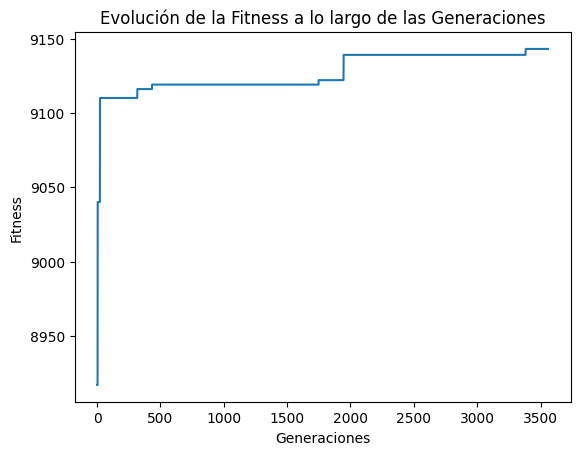

In [ ]:
import matplotlib.pyplot as plt
"""
Muestra la evolución del fitness a lo largo de las generaciones hasta que llega a la mejor solución
"""
first_index = 0
for i in range(len(fitness_history)):
    if fitness_history[i] == best_fitness:
        first_index = i
        break
print(first_index)
plt.plot(fitness_history[15:first_index])
plt.xlabel('Generaciones')
plt.ylabel('Fitness')
plt.title('Evolución de la Fitness a lo largo de las Generaciones')
plt.show()

# Prueba con diferentes tamaños de población inicial

En esta prueba se han probado los tamaños de población inicial de 10, 30, 50, 70 y 100 (ejecutado en las celdas anteriores)

Para cada prueba se obtiene la evolución del fitness y se guardan todas para mostrar una gráfica de dicha evolución por cada tamaño de población inicial.

Luego, se indica que tamaño de población ha producido mejores resultados.

In [ ]:
def evaluate_size(sizes):
    random.seed(SEED)
    new_fitness_history = []
    for size in sizes:
        population = []
        for _ in range(size):
            individuo = populate()
            population.append(individuo)

        best_solution = None
        best_fitness = None
        fitness_history = []
        generaciones_sin_mejora = 0
        for gen in range(generations):
            fitnesses = [fitness(ind) for ind in population]
            max_fitness_gen = max(fitnesses)
            if best_fitness == None or max_fitness_gen > best_fitness:
                best_fitness = max_fitness_gen
                best_solution = population[fitnesses.index(max_fitness_gen)]
                best_gen = gen
                generaciones_sin_mejora = 0
            else:
                generaciones_sin_mejora += 1

            new_population = []


            while len(new_population) < size:
                padre1 = rank_selection(population, fitnesses)
                padre2 = seleccion_torneo(population, fitnesses)

                if random.random() > CROSSOVER_RATE:
                    hijo1, hijo2 = crossover_uniforme(padre1, padre2)
                else:
                    hijo1, hijo2 = crossover_punto(padre1, padre2)

                new_population.append(mutation(hijo1))
                if len(new_population) < size:
                    new_population.append(mutation(hijo2))

            population = new_population[:size]
            for i in range(len(population)):
                if random.random() < FIX_RATE:
                    population[i] = reparar(population[i])
            fitness_history.append(best_fitness)

            if generaciones_sin_mejora > GENERACION_SIN_MEJORA:
                population = []
                for _ in range(size):
                    individuo = populate()
                    population.append(individuo)
                generaciones_sin_mejora = 0
                print("Población reiniciada por falta de mejora.")

            if gen % 500 == 0:
                peso = sum(best_solution[i] * objetos_peso[i] for i in range(len(best_solution)))
                valor = sum(best_solution[i] * objetos_valor[i] for i in range(len(best_solution)))
                print(f"Gen {gen} | Mejor fitness: {best_fitness} | Peso: {peso} | Valor: {valor} | Valido: {validar(best_solution)[0]}")
        new_fitness_history.append(fitness_history)
    return new_fitness_history

In [ ]:
sizes = [10, 30, 50, 70]
history = evaluate_size(sizes)
history.extend([fitness_last])

Gen 0 | Mejor fitness: 3893 | Peso: 597 | Valor: 4693 | Valido: False
Gen 500 | Mejor fitness: 8919 | Peso: 552 | Valor: 8919 | Valido: True
Gen 1000 | Mejor fitness: 9015 | Peso: 526 | Valor: 9015 | Valido: True
Gen 1500 | Mejor fitness: 9015 | Peso: 526 | Valor: 9015 | Valido: True
Gen 2000 | Mejor fitness: 9022 | Peso: 513 | Valor: 9022 | Valido: True
Gen 2500 | Mejor fitness: 9022 | Peso: 513 | Valor: 9022 | Valido: True
Gen 3000 | Mejor fitness: 9049 | Peso: 572 | Valor: 9049 | Valido: True
Gen 3500 | Mejor fitness: 9049 | Peso: 572 | Valor: 9049 | Valido: True
Gen 4000 | Mejor fitness: 9049 | Peso: 572 | Valor: 9049 | Valido: True
Población reiniciada por falta de mejora.
Gen 4500 | Mejor fitness: 9049 | Peso: 572 | Valor: 9049 | Valido: True
Gen 0 | Mejor fitness: 3657 | Peso: 599 | Valor: 4457 | Valido: False
Gen 500 | Mejor fitness: 9077 | Peso: 598 | Valor: 9077 | Valido: True
Gen 1000 | Mejor fitness: 9105 | Peso: 550 | Valor: 9105 | Valido: True
Gen 1500 | Mejor fitness: 91

Creación de la gráfica con los diferentes históricos.

En la leyenda se indica que tamaño de población inicial ha sido mejor y cual ha sido el valor del mejor fitness

Max fitness 9173 alcanzado en la generación 1813


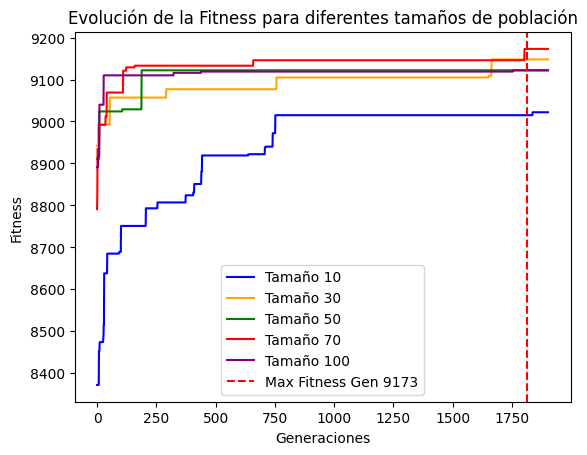

In [ ]:
max_fitness = max(max(h) for h in history)

# Buscar la generación en la que ocurrió por primera vez
if max_fitness in history[0]:
    max_generation = history[0].index(max_fitness)
    max_fitness_gen = max_fitness
    best_population = 10
elif max_fitness in history[1]:
    max_generation = history[1].index(max_fitness)
    max_fitness_gen = max_fitness
    best_population = 30
elif max_fitness in history[2]:
    max_generation = history[2].index(max_fitness)
    max_fitness_gen = max_fitness
    best_population = 50
elif max_fitness in history[3]:
    max_generation = history[3].index(max_fitness)
    max_fitness_gen = max_fitness
    best_population = 70
else:
    max_generation = history[4].index(max_fitness)
    max_fitness_gen = max_fitness
    best_population = 100

print(f'Max fitness {max_fitness} alcanzado en la generación {max_generation}')
plt.plot(history[0][10:max_generation+100], label='Tamaño 10', color='blue')
plt.plot(history[1][10:max_generation+100], label='Tamaño 30', color='orange')
plt.plot(history[2][10:max_generation+100], label='Tamaño 50', color='green')
plt.plot(history[3][10:max_generation+100], label='Tamaño 70', color='red')
plt.plot(history[4][10:max_generation+100], label='Tamaño 100', color='purple')
plt.xlabel('Generaciones')
plt.ylabel('Fitness')

color = 'blue' if max_fitness_gen in history[0] else 'orange' if max_fitness_gen in history[1] else 'green' if max_fitness_gen in history[2] else 'red' if max_fitness_gen in history[3] else 'purple'
plt.axvline(x=max_generation, color=color, linestyle='--', label=f'Max Fitness Gen {max_fitness}')
plt.title('Evolución de la Fitness para diferentes tamaños de población')
plt.legend()
plt.show()

In [ ]:
print(best_population)

70


# Test alterando MUTATION_RATE

En esta sección se evaluan diferentes tasas de mutación que son las siguientes: [0.05, 0.1, 0.15, 0.2].

Oara cada tasa de mutación se ejecuta el algoritmo geneético con la mejor población encontrada y al igual que en el notebook anterior, se muestra una gráfica con los históricos de cada prueba

In [ ]:
tasas_mutacion = [0.05, 0.1, 0.15, 0.2]
history_mutacion = []
for tasa in tasas_mutacion:
    MUTATION_RATE = tasa
    history_mutacion.extend(evaluate_size([best_population]))

Gen 0 | Mejor fitness: 4070 | Peso: 599 | Valor: 4670 | Valido: False
Gen 500 | Mejor fitness: 9118 | Peso: 583 | Valor: 9118 | Valido: True
Gen 1000 | Mejor fitness: 9118 | Peso: 583 | Valor: 9118 | Valido: True
Gen 1500 | Mejor fitness: 9133 | Peso: 576 | Valor: 9133 | Valido: True
Gen 2000 | Mejor fitness: 9133 | Peso: 576 | Valor: 9133 | Valido: True
Gen 2500 | Mejor fitness: 9133 | Peso: 576 | Valor: 9133 | Valido: True
Población reiniciada por falta de mejora.
Gen 3000 | Mejor fitness: 9133 | Peso: 576 | Valor: 9133 | Valido: True
Gen 3500 | Mejor fitness: 9133 | Peso: 576 | Valor: 9133 | Valido: True
Gen 4000 | Mejor fitness: 9153 | Peso: 586 | Valor: 9153 | Valido: True
Gen 4500 | Mejor fitness: 9153 | Peso: 586 | Valor: 9153 | Valido: True
Gen 0 | Mejor fitness: 4070 | Peso: 599 | Valor: 4670 | Valido: False
Gen 500 | Mejor fitness: 9118 | Peso: 583 | Valor: 9118 | Valido: True
Gen 1000 | Mejor fitness: 9118 | Peso: 583 | Valor: 9118 | Valido: True
Gen 1500 | Mejor fitness: 91

## Gráfica donde se muestra la evolución del fitness dependiendo del MUTATION_RATE utilizado

En dicha gráfica, se puede observar que variando la tasa de mutación en dicho rango no se consigue modificar los resultados, para ello, seleccionamos la tasa de mutación de 0.05 para el resto de las pruebas

Max fitness 9153 alcanzado en la generación 3528


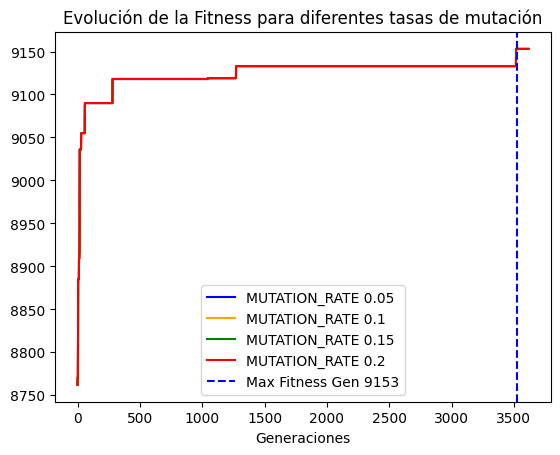

In [ ]:
max_fitness = max(max(h) for h in history_mutacion)

best_mutation_rate = None
# Buscar la generación en la que ocurrió por primera vez
if max_fitness in history_mutacion[0]:
    max_generation = history_mutacion[0].index(max_fitness)
    max_fitness_gen = max_fitness
    best_mutation_rate = 0.05
elif max_fitness in history_mutacion[1]:
    max_generation = history_mutacion[1].index(max_fitness)
    max_fitness_gen = max_fitness
    best_mutation_rate = 0.1
elif max_fitness in history_mutacion[2]:
    max_generation = history_mutacion[2].index(max_fitness)
    max_fitness_gen = max_fitness
    best_mutation_rate = 0.15
else:
    max_generation = history_mutacion[3].index(max_fitness)
    best_mutation_rate = 0.2
    max_fitness_gen = max_fitness

print(f'Max fitness {max_fitness} alcanzado en la generación {max_generation}')

plt.plot(history_mutacion[0][10:max_generation+100], label='MUTATION_RATE 0.05', color='blue')
plt.plot(history_mutacion[1][10:max_generation+100], label='MUTATION_RATE 0.1', color='orange')
plt.plot(history_mutacion[2][10:max_generation+100], label='MUTATION_RATE 0.15', color='green')
plt.plot(history_mutacion[3][10:max_generation+100], label='MUTATION_RATE 0.2', color='red')

color = 'blue' if max_fitness_gen in history_mutacion[0] else 'orange' if max_fitness_gen in history_mutacion[1] else 'green' if max_fitness_gen in history_mutacion[2] else 'red'
plt.axvline(x=max_generation, color=color, linestyle='--', label=f'Max Fitness Gen {max_fitness}')

plt.xlabel('Generaciones')
plt.title('Evolución de la Fitness para diferentes tasas de mutación')
plt.legend()
plt.show()

In [ ]:
print(best_mutation_rate)

0.05


## Pruebas aplicando diferentes CROSSOVER_RATE

En esta sección se evaluan diferentes tasas de cruce que son las siguientes: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

Para cada tasa de cruce se ejecuta el algoritmo genético y se evaluan los resultados.
Por ejemplo, si una tasa de cruce es del 40%, significa que el cruce uniforme tiene una probabilidad de ejecutarse un 60% y el cruce de dos puntos un 40%

In [ ]:
MUTATION_RATE = best_mutation_rate
crossover_rates = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

history_crossover = []
for rate in crossover_rates:
    CROSSOVER_RATE = rate
    history_crossover.extend(evaluate_size([best_population]))

Gen 0 | Mejor fitness: 4070 | Peso: 599 | Valor: 4670 | Valido: False
Gen 500 | Mejor fitness: 9119 | Peso: 557 | Valor: 9119 | Valido: True
Gen 1000 | Mejor fitness: 9119 | Peso: 557 | Valor: 9119 | Valido: True
Gen 1500 | Mejor fitness: 9119 | Peso: 557 | Valor: 9119 | Valido: True
Población reiniciada por falta de mejora.
Gen 2000 | Mejor fitness: 9119 | Peso: 557 | Valor: 9119 | Valido: True
Gen 2500 | Mejor fitness: 9125 | Peso: 585 | Valor: 9125 | Valido: True
Gen 3000 | Mejor fitness: 9127 | Peso: 565 | Valor: 9127 | Valido: True
Gen 3500 | Mejor fitness: 9127 | Peso: 565 | Valor: 9127 | Valido: True
Gen 4000 | Mejor fitness: 9193 | Peso: 594 | Valor: 9193 | Valido: True
Gen 4500 | Mejor fitness: 9193 | Peso: 594 | Valor: 9193 | Valido: True
Gen 0 | Mejor fitness: 4070 | Peso: 599 | Valor: 4670 | Valido: False
Gen 500 | Mejor fitness: 9087 | Peso: 578 | Valor: 9087 | Valido: True
Gen 1000 | Mejor fitness: 9130 | Peso: 600 | Valor: 9130 | Valido: True
Gen 1500 | Mejor fitness: 91

## Gráfica para ver la evolución del fitness utilizando diferentes valores en CROSSOVER_RATE

En la gráfica se puede observar que si aplicamos una baja probabilidad de aplicar la tasa de cruce al cruce de dos puntos y una alta al cruce uniforme, se obtienen los mejores resultados

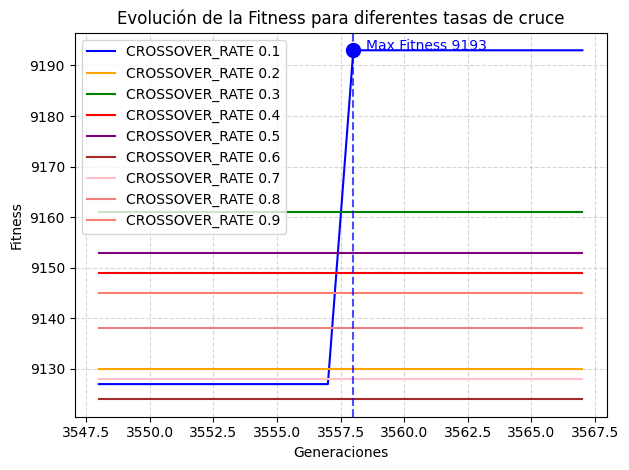

In [ ]:
import matplotlib.pyplot as plt

# Definir los crossover rates y colores
crossover_rates = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'lightcoral', 'salmon']

# Encontrar máximo fitness
max_fitness = max(max(h) for h in history_crossover)
best_crossover_rate = None
max_generation = None

for i, h in enumerate(history_crossover):
    if max_fitness in h:
        max_generation = h.index(max_fitness)
        best_crossover_rate = crossover_rates[i]
        break

# Rango de generaciones a mostrar
start_gen = max(0, max_generation - 10)
end_gen = min(len(history_crossover[0]), max_generation + 10)

# Leyenda
for i, h in enumerate(history_crossover):
    plt.plot(range(start_gen, end_gen), h[start_gen:end_gen], label=f'CROSSOVER_RATE {crossover_rates[i]}', color=colors[i])

# Línea vertical y marcador para el máximo
plt.axvline(x=max_generation, color=colors[crossover_rates.index(best_crossover_rate)], linestyle='--', alpha=0.7)
plt.scatter(max_generation, max_fitness, color=colors[crossover_rates.index(best_crossover_rate)], s=100, zorder=5)
plt.text(max_generation + 0.5, max_fitness, f'Max Fitness {max_fitness}', color=colors[crossover_rates.index(best_crossover_rate)])

plt.xlabel('Generaciones')
plt.ylabel('Fitness')
plt.title('Evolución de la Fitness para diferentes tasas de cruce')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
print(best_crossover_rate)

0.1


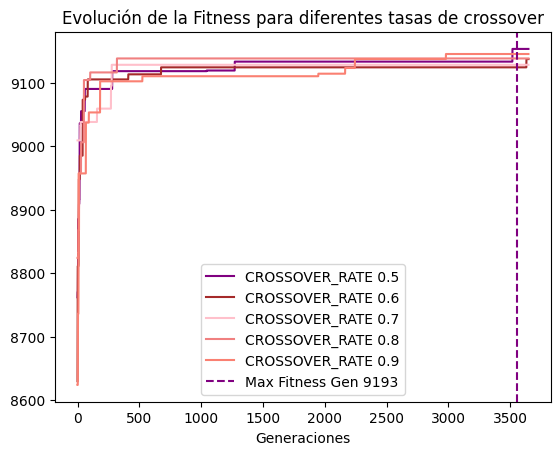

In [ ]:
plt.plot(history_crossover[4][10:max_generation+100], label='CROSSOVER_RATE 0.5', color='purple')
plt.plot(history_crossover[5][10:max_generation+100], label='CROSSOVER_RATE 0.6', color='brown')
plt.plot(history_crossover[6][10:max_generation+100], label='CROSSOVER_RATE 0.7', color='pink')
plt.plot(history_crossover[7][10:max_generation+100], label='CROSSOVER_RATE 0.8', color='lightcoral')
plt.plot(history_crossover[8][10:max_generation+100], label='CROSSOVER_RATE 0.9', color='salmon')

color = 'blue' if max_fitness_gen in history_crossover[0] else 'orange' if max_fitness_gen in history_crossover[1] else 'green' if max_fitness_gen in history_crossover[2] else 'red' if max_fitness_gen in history_crossover[3] else 'purple' if max_fitness_gen in history_crossover[4] else 'brown' if max_fitness_gen in history_crossover[5] else 'pink' if max_fitness_gen in history_crossover[6] else 'lightcoral' if max_fitness_gen in history_crossover[7] else 'salmon'
plt.axvline(x=max_generation, color=color, linestyle='--', label=f'Max Fitness Gen {max_fitness}')

plt.xlabel('Generaciones')
plt.title('Evolución de la Fitness para diferentes tasas de crossover')
plt.legend()
plt.show()

## Pruebas aplicando diferentes probabilidades en la tasa de arreglo de un individuo

En esta sección se evaluan diferentes tasas de arreglo de un individuo. Debido a las restricciones del problema, al realizar una modificación al individuo se tiene muchas probabilidades de que no se cumplan las restricciones, para ello se aplica la función de arreglo, para evitar crear nuevos individuos que no sean válidos.

In [ ]:
fix_rates = [0, 0.25, 0.5, 0.75, 1]
history_fix = []
MUTATION_RATE = best_mutation_rate
CROSSOVER_RATE = best_crossover_rate
for rate in fix_rates:
    FIX_RATE = rate
    history_fix.extend(evaluate_size([best_population]))

max_fitness = max(max(h) for h in history_fix)
best_fix_rate = None
# Buscar la generación en la que ocurrió por primera vez
if max_fitness in history_fix[0]:
    max_generation = history_fix[0].index(max_fitness)
    max_fitness_gen = max_fitness
    best_fix_rate = 0
elif max_fitness in history_fix[1]:
    max_generation = history_fix[1].index(max_fitness)
    max_fitness_gen = max_fitness
    best_fix_rate = 0.25
elif max_fitness in history_fix[2]:
    max_generation = history_fix[2].index(max_fitness)
    max_fitness_gen = max_fitness
    best_fix_rate = 0.5
elif max_fitness in history_fix[3]:
    max_generation = history_fix[3].index(max_fitness)
    max_fitness_gen = max_fitness
    best_fix_rate = 0.75
else:
    max_generation = history_fix[4].index(max_fitness)
    max_fitness_gen = max_fitness
    best_fix_rate = 1

print(f'Max fitness {max_fitness} alcanzado en la generación {max_generation}')



Gen 0 | Mejor fitness: 4070 | Peso: 599 | Valor: 4670 | Valido: False
Gen 500 | Mejor fitness: 7008 | Peso: 686 | Valor: 9368 | Valido: False
Gen 1000 | Mejor fitness: 7008 | Peso: 686 | Valor: 9368 | Valido: False
Gen 1500 | Mejor fitness: 7008 | Peso: 686 | Valor: 9368 | Valido: False
Población reiniciada por falta de mejora.
Gen 2000 | Mejor fitness: 7008 | Peso: 686 | Valor: 9368 | Valido: False
Gen 2500 | Mejor fitness: 7008 | Peso: 686 | Valor: 9368 | Valido: False
Gen 3000 | Mejor fitness: 7008 | Peso: 686 | Valor: 9368 | Valido: False
Población reiniciada por falta de mejora.
Gen 3500 | Mejor fitness: 7008 | Peso: 686 | Valor: 9368 | Valido: False
Gen 4000 | Mejor fitness: 7008 | Peso: 686 | Valor: 9368 | Valido: False
Gen 4500 | Mejor fitness: 7008 | Peso: 686 | Valor: 9368 | Valido: False
Población reiniciada por falta de mejora.
Gen 0 | Mejor fitness: 4070 | Peso: 599 | Valor: 4670 | Valido: False
Gen 500 | Mejor fitness: 8787 | Peso: 489 | Valor: 8787 | Valido: True
Gen 100

## Gráfica con la evolución del fitness con diferentes FIX_RATE

En la gráfica se puede ver que con una tasa de arreglo muy baja no se obtiene una buena solución, pero a medida que aumentamos la tasa de arreglo conseguimos mejores resultados

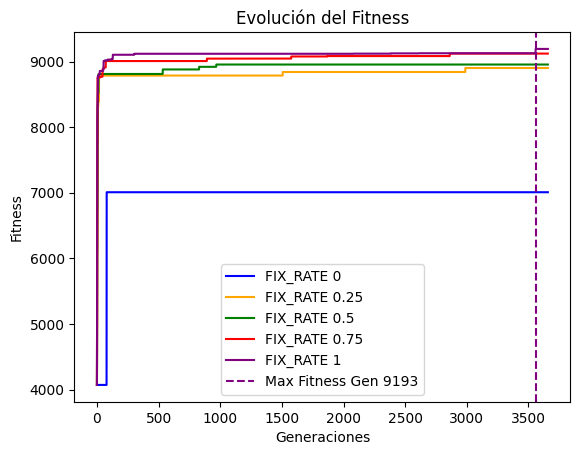

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_fix[0][:max_generation+100], label='FIX_RATE 0', color='blue')
plt.plot(history_fix[1][:max_generation+100], label='FIX_RATE 0.25', color='orange')
plt.plot(history_fix[2][:max_generation+100], label='FIX_RATE 0.5', color='green')
plt.plot(history_fix[3][:max_generation+100], label='FIX_RATE 0.75', color='red')
plt.plot(history_fix[4][:max_generation+100], label='FIX_RATE 1', color='purple')

color = 'blue' if max_fitness_gen in history_fix[0] else 'orange' if max_fitness_gen in history_fix[1] else 'green' if max_fitness_gen in history_fix[2] else 'red' if max_fitness_gen in history_fix[3] else 'purple'
plt.axvline(x=max_generation, color=color, linestyle='--', label=f'Max Fitness Gen {max_fitness}')
plt.xlabel('Generaciones')
plt.ylabel('Fitness')
plt.title('Evolución del Fitness')
plt.legend()
plt.show()

# Ejecución con los mejores parámetros encontrados

En esta sección evaluo los resultados con los mejores parámetros y comparo la población final del algoritmo para que se puede ver como los últimos individuos cumplen la mayoría de las restricciones

In [ ]:
def evaluate_size(sizes):
    random.seed(SEED)
    new_fitness_history = []
    for size in sizes:
        population = []
        for _ in range(size):
            individuo = populate()
            population.append(individuo)

        best_solution = None
        best_fitness = None
        fitness_history = []
        generaciones_sin_mejora = 0
        for gen in range(generations):
            fitnesses = [fitness(ind) for ind in population]
            max_fitness_gen = max(fitnesses)
            if best_fitness == None or max_fitness_gen > best_fitness:
                best_fitness = max_fitness_gen
                best_solution = population[fitnesses.index(max_fitness_gen)]
                best_gen = gen
                generaciones_sin_mejora = 0
            else:
                generaciones_sin_mejora += 1

            new_population = []


            while len(new_population) < size:
                padre1 = rank_selection(population, fitnesses)
                padre2 = seleccion_torneo(population, fitnesses)

                if random.random() > CROSSOVER_RATE:
                    hijo1, hijo2 = crossover_uniforme(padre1, padre2)
                else:
                    hijo1, hijo2 = crossover_punto(padre1, padre2)

                new_population.append(mutation(hijo1))
                if len(new_population) < size:
                    new_population.append(mutation(hijo2))

            population = new_population[:size]
            for i in range(len(population)):
                if random.random() < FIX_RATE:
                    population[i] = reparar(population[i])
            fitness_history.append(best_fitness)

            if generaciones_sin_mejora > GENERACION_SIN_MEJORA:
                population = []
                for _ in range(size):
                    individuo = populate()
                    population.append(individuo)
                generaciones_sin_mejora = 0
                print("Población reiniciada por falta de mejora.")

            if gen % 500 == 0:
                peso = sum(best_solution[i] * objetos_peso[i] for i in range(len(best_solution)))
                valor = sum(best_solution[i] * objetos_valor[i] for i in range(len(best_solution)))
                print(f"Gen {gen} | Mejor fitness: {best_fitness} | Peso: {peso} | Valor: {valor} | Valido: {validar(best_solution)[0]}")
        new_fitness_history.append(fitness_history)
    return new_fitness_history, population

In [ ]:
MUTATION_RATE = best_mutation_rate
CROSSOVER_RATE = best_crossover_rate
FIX_RATE = best_fix_rate

history_final, final_population = evaluate_size([best_population])

Gen 0 | Mejor fitness: 4070 | Peso: 599 | Valor: 4670 | Valido: False
Gen 500 | Mejor fitness: 9119 | Peso: 557 | Valor: 9119 | Valido: True
Gen 1000 | Mejor fitness: 9119 | Peso: 557 | Valor: 9119 | Valido: True
Gen 1500 | Mejor fitness: 9119 | Peso: 557 | Valor: 9119 | Valido: True
Población reiniciada por falta de mejora.
Gen 2000 | Mejor fitness: 9119 | Peso: 557 | Valor: 9119 | Valido: True
Gen 2500 | Mejor fitness: 9125 | Peso: 585 | Valor: 9125 | Valido: True
Gen 3000 | Mejor fitness: 9127 | Peso: 565 | Valor: 9127 | Valido: True
Gen 3500 | Mejor fitness: 9127 | Peso: 565 | Valor: 9127 | Valido: True
Gen 4000 | Mejor fitness: 9193 | Peso: 594 | Valor: 9193 | Valido: True
Gen 4500 | Mejor fitness: 9193 | Peso: 594 | Valor: 9193 | Valido: True


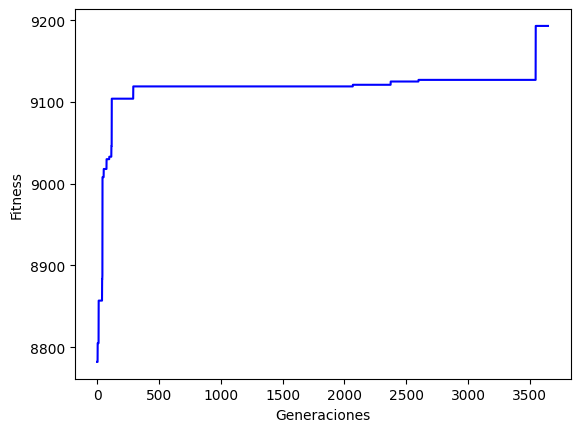

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history_final[0][10:max_generation+100], label='Tamaño óptimo', color='blue')
plt.xlabel('Generaciones')
plt.ylabel('Fitness')
plt.show()

## Gráficas de la población final

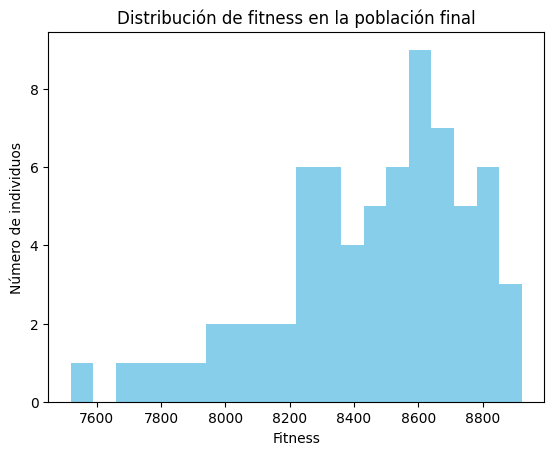

In [ ]:
def plot_fitnesses(fitnesses_final):
  plt.hist(fitnesses_final, bins=20, color='skyblue')
  plt.xlabel('Fitness')
  plt.ylabel('Número de individuos')
  plt.title('Distribución de fitness en la población final')
  plt.show()
fitnesses_final = [fitness(ind) for ind in final_population]
plot_fitnesses(fitnesses_final)



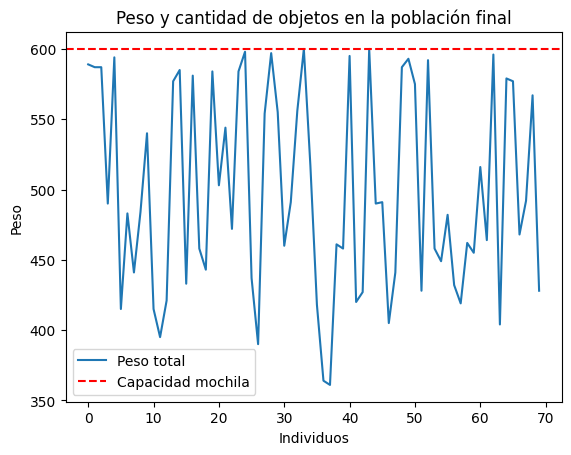

In [ ]:
def plot_peso(peso_history):
  plt.plot(peso_history, label='Peso total')
  plt.axhline(capacidad_mochila, color='red', linestyle='--', label='Capacidad mochila')
  plt.xlabel('Individuos')
  plt.ylabel('Peso')
  plt.title('Peso y cantidad de objetos en la población final')
  plt.legend()
  plt.show()

peso_history = [sum(ind[i]*objetos_peso[i] for i in range(N)) for ind in final_population]
plot_peso(peso_history)


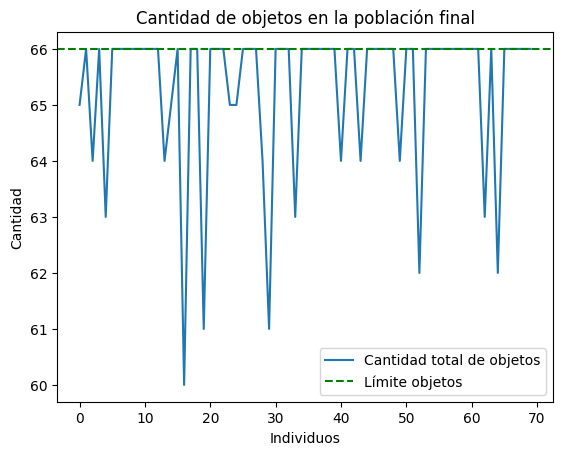

In [ ]:
def plot_cantidad(cantidad_history):
  plt.plot(cantidad_history, label='Cantidad total de objetos')
  plt.axhline(limite_objetos, color='green', linestyle='--', label='Límite objetos')
  plt.xlabel('Individuos')
  plt.ylabel('Cantidad')
  plt.title('Cantidad de objetos en la población final')
  plt.legend()
  plt.show()

cantidad_history = [sum(ind) for ind in final_population]
plot_cantidad(cantidad_history)




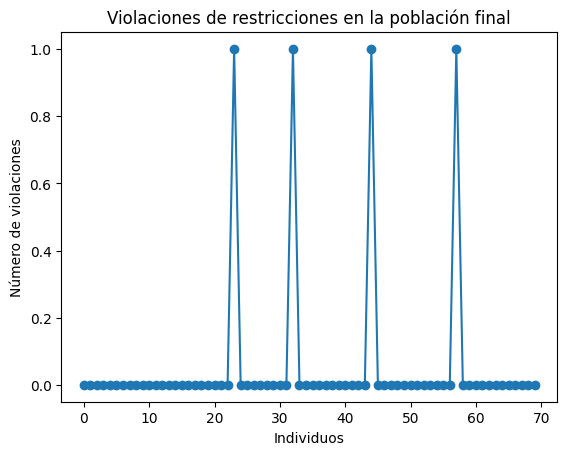

In [ ]:
def plot_violaciones(violaciones_history):
  plt.plot(violaciones_history, marker='o')
  plt.xlabel('Individuos')
  plt.ylabel('Número de violaciones')
  plt.title('Violaciones de restricciones en la población final')
  plt.show()
violaciones_history = []
for ind in final_population:
    _, violaciones = validar(ind)
    violaciones_history.append(len(violaciones))
plot_violaciones(violaciones_history)



# Información de la población inicial

Información de la población inicial para que se vea la diferencia entre la población final del algoritmo genético

In [ ]:
random.seed(SEED)
population = []
for _ in range(best_population):
    individuo = populate()
    population.append(individuo)

fitnesses_final = [fitness(ind) for ind in population]
peso_history = [sum(ind[i]*objetos_peso[i] for i in range(N)) for ind in population]
cantidad_history = [sum(ind) for ind in population]
violaciones_history = []
for ind in population:
    _, violaciones = validar(ind)
    violaciones_history.append(len(violaciones))



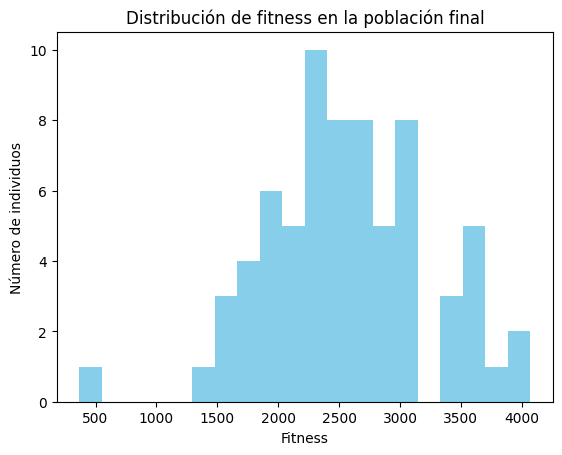

In [ ]:
plot_fitnesses(fitnesses_final)

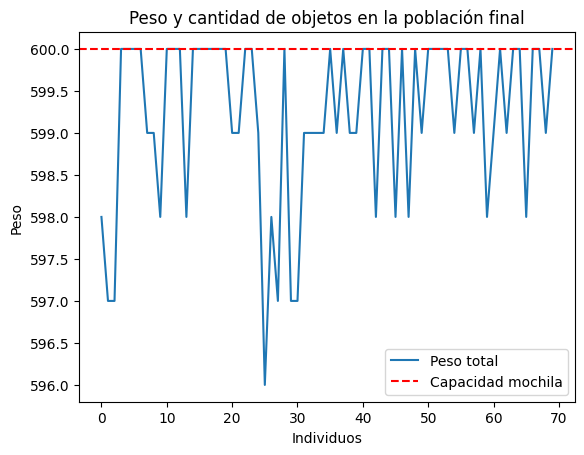

In [ ]:
plot_peso(peso_history)

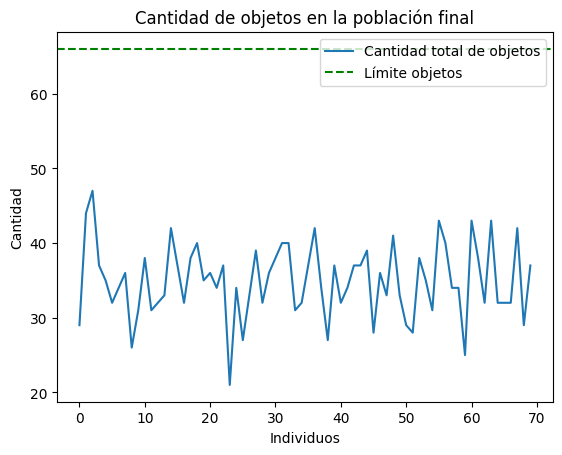

In [ ]:
plot_cantidad(cantidad_history)

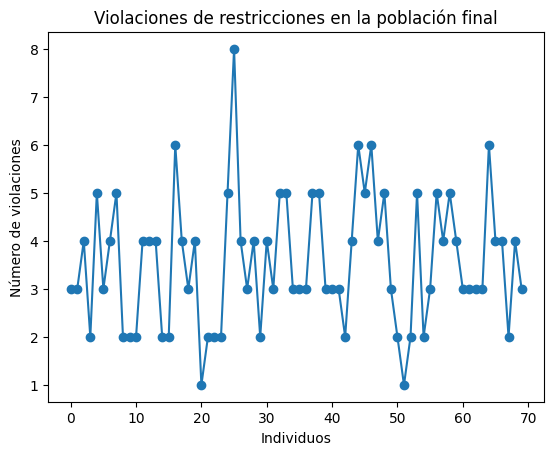

In [ ]:
plot_violaciones(violaciones_history)